# First do some pip installs to run the code in this notebook!
Hi DIGIT 210! Dr. B here with some notes on pip installations to run this notebook:
Go out to your shell, **make sure you've activated your virtual environment** on your folder hosting this notebook. 

In your activated (.venv) at command line, run the following:

```shell
pip install "numpy<2.0"
pip install torch transformers
pip install --upgrade torch 
pip install ipywidgets
```

|<h2>Substack post:</h2>|<h1><a href="https://open.substack.com/pub/mikexcohen/p/llm-breakdown-16-tokenization-words" target="_blank">LLM breakdown 1/6: Tokenization (words to integers)</a></h1>|
|-|:-:|
|<h2>Teacher:<h2>|<h1>Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h1>|

<br>
Original notebook is here: <a href="https://github.com/mikexcohen/Substack/blob/main/MLonLLMs/LLMbreakdown_1_tokens.ipynb">https://github.com/mikexcohen/Substack/blob/main/MLonLLMs/LLMbreakdown_1_tokens.ipynb</a>

<i><b>Using the code without reading the post may lead to confusion or errors.</b></i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec

# pytorch libraries
import torch
import torch.nn.functional as F

OSError: [WinError 4551] An Application Control policy has blocked this file. Error loading "C:\Users\Tara\Documents\school-apps\GitHub\Digit210\python-nlp\.venv\Lib\site-packages\torch\lib\torch_python.dll" or one of its dependencies.

In [ ]:
### Run this cell only if you're using "dark mode"

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'figure.facecolor': '#171717',
    'figure.edgecolor': '#171717',
    'axes.facecolor':   '#171717',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

# Import GPT2's tokenizer

In [ ]:
# GPT2 tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
dir(tokenizer)

In [ ]:
# how many tokens in the lexicon?
tokenizer.vocab_size

## DIGIT 210: What other tokenizers are available in torch transformers?
EBB: We can try:

### Word-piece / Subword Tokenizers

* BertTokenizer — classic WordPiece, good contrast to BPE
* GPT2Tokenizer — Byte-Pair Encoding (BPE), what they're already using
* RobertaTokenizer — BPE variant, similar to GPT-2 but with different vocab
* XLMRobertaTokenizer — SentencePiece BPE, multilingual

### SentencePiece-based

* T5Tokenizer — unigram SentencePiece, good for seq2seq discussion
AlbertTokenizer — SentencePiece with vocab sharing tricks
LlamaTokenizer — SentencePiece BPE, popular for modern LLM discussion



In [ ]:
# ebb: Just for fun, let's try multiple tokenizers! 
from transformers import (
    GPT2Tokenizer,
    BertTokenizer,
    RobertaTokenizer,
    T5Tokenizer,
    AutoTokenizer,
)

# Load tokenizers (downloads on first run, cached after)
tokenizers = {
    "GPT-2  (BPE)":         GPT2Tokenizer.from_pretrained("gpt2"),
    "BERT   (WordPiece)":   BertTokenizer.from_pretrained("bert-base-uncased"),
    "RoBERTa(BPE)":         RobertaTokenizer.from_pretrained("roberta-base"),
    "T5     (SentencePiece)":T5Tokenizer.from_pretrained("t5-small"),
    "Auto   → DistilBERT":  AutoTokenizer.from_pretrained("distilbert-base-uncased"),
}

# Some random tokens

In [ ]:
for t in np.random.randint(tokenizer.vocab_size,size=10):
  print(f'Token {t:>5} is "{tokenizer.decode([t])}"')

# Common vs. uncommon letter pairs

In [ ]:
print(tokenizer.encode('th'))
print(tokenizer.encode('tq'))

# Tokenizing a sentence

In [ ]:


txt = 'I like the longer-form posts on Substack.'

tokens = tokenizer.encode(txt)
print(f'The sentence contains {len(txt)} characters and {len(tokens)} tokens.\n')

print('  Index  |  Token')
print('---------+-----------')
for t in tokens:
  print(f'  {t:>5}  |  "{tokenizer.decode([t])}"')

# Importance of spaces

In [2]:
words = [ 'banana',' banana',' Banana',
          'substack',' substack',
          'like',' like' ]

for w in words:
  toks = tokenizer.encode(w)
  print(f'{len(toks)} tokens form "{w}" ({toks})')

NameError: name 'tokenizer' is not defined

# Any r's in strawberry?

In [3]:
tokenizer.encode(' strawberry')
tokenizer.encode('r')

NameError: name 'tokenizer' is not defined

# Tokenization in different languages

In [4]:
languages = ['English','Spanish','Arabic','Persian','Lithuanian','Chinese','Tamil','Esperanto']

sentences = [ 'Blue towels are great because they remind you of the sea, although the sea is wet and towels work better when they are dry.',
              'Las toallas azules son geniales porque recuerdan al mar, aunque el mar está mojado y las toallas funcionan mejor cuando están secas.',
              'تعتبر المناشف الزرقاء رائعة لأنها تذكرك بالبحر، على الرغم من أن البحر مبلل والمناشف تعمل بشكل أفضل عندما تكون جافة.',
              'حوله‌های آبی عالی هستند زیرا شما را به یاد دریا می‌اندازند، اگرچه دریا مرطوب است و حوله‌ها وقتی خشک باشند بهتر عمل می‌کنند.',
              'Mėlyni rankšluosčiai puikūs, nes primena jūrą, nors jūra yra šlapia, o rankšluosčiai geriau tinka, kai yra sausi.',
              '蓝色毛巾很棒，因为它们会让您想起大海，尽管海水是湿的，而毛巾在干燥时效果更好。',
              'நீல நிற துண்டுகள் சிறந்தவை, ஏனென்றால் அவை கடலை நினைவூட்டுகின்றன, இருப்பினும் கடல் ஈரமாக இருக்கும், துண்டுகள் உலர்ந்திருக்கும் போது சிறப்பாக வேலை செய்யும்.',
              'Bluaj mantukoj estas bonegaj ĉar ili memorigas vin pri la maro, kvankam la maro estas malseka kaj mantukoj funkcias pli bone kiam ili estas sekaj.',
]

In [5]:
# table header
print(' Language  |  Chars  |  tokens ')
print('-'*31)

tokenCount = []
charCount = []

for lang,text in zip(languages,sentences):

  # tokenize the text
  tokens = tokenizer.encode(text)

  # print the result
  print(f'{lang:>10} |   {len(text):3}   |  {len(tokens):3}')

  tokenCount.append(len(tokens))
  charCount.append(len(text))

 Language  |  Chars  |  tokens 
-------------------------------


NameError: name 'tokenizer' is not defined

ValueError: zero-size array to reduction operation maximum which has no identity

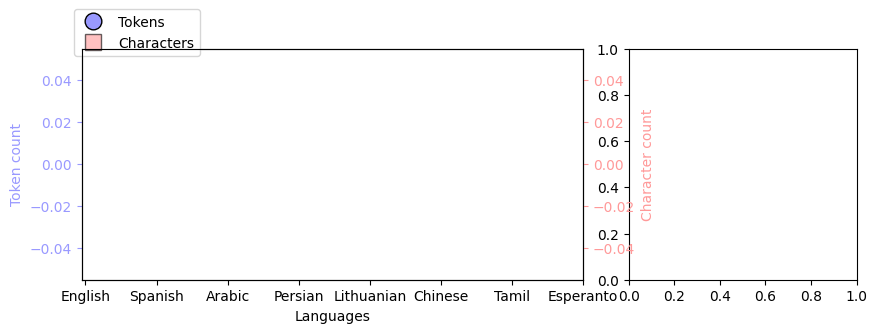

In [6]:
fig = plt.figure(figsize=(10,3))
gs = gridspec.GridSpec(1,3,figure=fig)
ax1 = fig.add_subplot(gs[:-1])
ax2 = fig.add_subplot(gs[-1])


# plot token count in blue
ax1.plot(tokenCount,'ko',markerfacecolor=[.6,.6,1],markersize=12,label='Tokens')
ax1.set(xlabel='Languages',xticks=range(len(languages)),xticklabels=languages)
ax1.set_ylabel('Token count',color=[.6,.6,1])
ax1.tick_params(axis='y',colors=[.6,.6,1])

# plot character count in red
axx = ax1.twinx()
axx.plot(charCount,'ks',markerfacecolor=[1,.6,.6,.6],markersize=12,label='Characters')
axx.spines['right'].set_visible(True)
axx.set_ylabel('Character count',color=[1,.6,.6])
axx.tick_params(axis='y',colors=[1,.6,.6])

# get both legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = axx.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, bbox_to_anchor=[.25,1.2])


ymax = np.max([np.max(tokenCount),np.max(charCount)])+20
ax2.plot(charCount,tokenCount,'ko',markerfacecolor=[.6,.6,1],markersize=12)
ax2.plot([0,ymax],[0,ymax],'--',color='#8cf5ff',zorder=-1)

ax2.set(xlabel='Character count',ylabel='Token count',xlim=[0,ymax],ylim=[0,ymax])

plt.tight_layout()
plt.show()

## DIGIT 210: Okay, let's try this with the range of different tokenizers! 

In [7]:

# ── Multilingual Tokenizer Comparison ────────────────────────────────────────
from transformers import (
    GPT2Tokenizer,
    BertTokenizer,
    AutoTokenizer,
)
# GPT-2: English-centric BPE
# BERT multilingual: WordPiece trained on 104 languages
# XLM-RoBERTa: BPE trained on 100 languages (much stronger on non-Latin scripts)
tokenizers = {
    "GPT-2 (EN-only BPE)":      GPT2Tokenizer.from_pretrained("gpt2"),
    "mBERT (multilingual)":     BertTokenizer.from_pretrained("bert-base-multilingual-cased"),
    "XLM-RoBERTa (multilingual)": AutoTokenizer.from_pretrained("xlm-roberta-base"),
}

# ── Token count comparison across languages & tokenizers ─────────────────────
print(f"{'Language':<12}", end="")
for name in tokenizers:
    print(f"  {name:>26}", end="")
print()
print("─" * 95)

for lang, sent in zip(languages, sentences):
    print(f"{lang:<12}", end="")
    for tok in tokenizers.values():
        n = len(tok.tokenize(sent))
        print(f"  {n:>26}", end="")
    print()

C:\Users\Tara\Documents\school-apps\GitHub\Digit210\python-nlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: [WinError 4551] An Application Control policy has blocked this file. Error loading "C:\Users\Tara\Documents\school-apps\GitHub\Digit210\python-nlp\.venv\Lib\site-packages\torch\lib\torch_python.dll" or one of its dependencies.

In [ ]:
# ── Inspect tokens for one language ──────────────────────────────────────────
focus_lang = "Arabic"   # ← change this to any language in your list!
idx = languages.index(focus_lang)
sent = sentences[idx]

print(f"Language: {focus_lang}")
print(f"Sentence: {sent}\n")

for name, tok in tokenizers.items():
    tokens = tok.tokenize(sent)
    print(f"{name}  ({len(tokens)} tokens):")
    print(f"  {tokens}\n")

# Tokenization in BERT

In [ ]:
from transformers import BertTokenizer
tokenizerB = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
words = [ 'banana',' banana',' Banana',
          'substack',' substack',
          'like',' like',
          '.', ',', ' ']

for w in words:
  toks = tokenizerB.encode(w,add_special_tokens=False)
  print(f'{len(toks)} tokens form "{w}" ({toks})')

In [ ]:
text= "I am learning this I think?"